# Task 1 — Data Preprocessing & Cleaning
**Course:** MOP 3231 · Machine Learning (Python)  
**Student:** Daniil Li  
**Student ID:** S24072175 (Random seed: 2175)

In [1]:
import sys, platform
import numpy as np
import pandas as pd
import sklearn
import matplotlib

print("Python  ", sys.version.split()[0], "|", platform.python_version())
print("NumPy   ", np.__version__)
print("pandas  ", pd.__version__)
print("scikit  ", sklearn.__version__)
print("mpl     ", matplotlib.__version__)

Python   3.12.8 | 3.12.8
NumPy    2.0.2
pandas   2.3.3
scikit   1.6.1
mpl      3.9.4


## Step 2 · Load and Inspect
Student ID last 4 digits: **2175**.
We load the raw dataset and take a 90% sample of listings using `random_state=2175`.

In [2]:
import pandas as pd

raw = pd.read_csv("data/almaty_apartments_raw.csv")
ids = raw["listing_id"].drop_duplicates().sample(frac=0.9, random_state=2175)
df = raw[raw["listing_id"].isin(ids)].reset_index(drop=True)

print("df.shape:", df.shape)
print("\ndf.dtypes:\n", df.dtypes)
print("\ndf.isna().sum():\n", df.isna().sum())
print("\ndf.describe(include='all').T:\n", df.describe(include="all").T)

df.shape: (1153, 11)

df.dtypes:
 listing_id           object
listed_date          object
district             object
rooms                object
area_m2              object
floor                 int64
total_floors          int64
year_built          float64
building_type        object
ceiling_height_m    float64
price_kzt            object
dtype: object

df.isna().sum():
 listing_id            0
listed_date           0
district              0
rooms                 0
area_m2               0
floor                 0
total_floors          0
year_built           59
building_type         0
ceiling_height_m    141
price_kzt             0
dtype: int64

df.describe(include='all').T:
                    count unique         top freq         mean        std  min  \
listing_id          1153   1080   ALM-11147    3          NaN        NaN  NaN   
listed_date         1153    246  2026-03-23   10          NaN        NaN  NaN   
district            1153     48       Medeu  141          NaN        NaN 

### Step 2 Report: Spec, Grain, and Mis-typed Columns

**Grain of the table:**
One row represents a single posting of an apartment listing in Almaty. A single apartment (`listing_id`) can appear multiple times if it was reposted (possibly at different dates or prices) or duplicated.

**Mis-typed columns and causes:**
1. `listed_date` (read as `object`): ISO dates formatted as `YYYY-MM-DD` are stored as plain strings in CSV; pandas does not automatically parse them into datetime objects on read without explicit parameters.
2. `rooms` (read as `object`): The column contains integer counts stored as text, plus the word string `'studio'` for studio apartments instead of a numeric digit `1`.
3. `area_m2` (read as `object`): Contains mixed decimal separators (`.` and `,`) as well as string unit suffixes (e.g., `' m²'`), preventing numeric conversion by pandas.
4. `price_kzt` (read as `object`): Contains thousand separators (spaces and commas) and currency symbols (`' ₸'`), which causes pandas to treat the column as object text.

**Validation Specification:**
- `listing_id`: non-null string identifier matching pattern `ALM-\d+`.
- `listed_date`: valid date between `2026-01-01` and `2026-12-31`.
- `district`: string belonging to the 8 official Almaty districts: `Alatau`, `Almaly`, `Auezov`, `Bostandyk`, `Medeu`, `Nauryzbay`, `Turksib`, `Zhetysu`.
- `rooms`: positive integer, typically between 1 and 10.
- `area_m2`: positive float, realistic range 15 to 500 m².
- `floor`: positive integer $\ge 1$. Must satisfy `floor <= total_floors`.
- `total_floors`: positive integer $\ge 1$, realistic range 1 to 50.
- `year_built`: integer year between 1900 and 2026 (never 0).
- `building_type`: categorical, one of `'panel'`, `'brick'`, `'monolith'`.
- `ceiling_height_m`: float between 2.0 and 5.0 metres (never 0.0).
- `price_kzt`: positive number, realistic range 10,000,000 to 500,000,000 ₸.

## Step 3 · Clean Data
### 3a · Duplicates and reposts
We first remove exact duplicate rows. Then, for reposts (same `listing_id` posted multiple times with different dates or prices), we sort by `listed_date` and keep the latest posting (`keep='last'`).  
*Justification:* The most recent listing reflects the seller's updated price and current market availability; earlier listings are obsolete historical snapshots.

In [3]:
# Track cleaning operations in a log
cleaning_log = []

# 3a. Exact duplicates
rows_before = len(df)
df = df.drop_duplicates()
rows_after = len(df)
exact_dup_removed = rows_before - rows_after
cleaning_log.append({
    "Step": "3a",
    "Operation": "Remove exact duplicates",
    "Rows before": rows_before,
    "Rows after": rows_after,
    "Cells changed": f"{exact_dup_removed} rows dropped"
})
print(f"Removed {exact_dup_removed} exact duplicates: {rows_before} -> {rows_after}")

# 3a. Reposts (same listing_id with different dates/prices)
df["listed_date"] = pd.to_datetime(df["listed_date"])
rows_before = len(df)
df = df.sort_values("listed_date").drop_duplicates("listing_id", keep="last").reset_index(drop=True)
rows_after = len(df)
reposts_removed = rows_before - rows_after
cleaning_log.append({
    "Step": "3a",
    "Operation": "Resolve reposts (keep latest by date)",
    "Rows before": rows_before,
    "Rows after": rows_after,
    "Cells changed": f"{reposts_removed} rows dropped"
})
print(f"Resolved reposts: removed {reposts_removed} older postings: {rows_before} -> {rows_after}")

Removed 31 exact duplicates: 1153 -> 1122
Resolved reposts: removed 42 older postings: 1122 -> 1080


### 3b · Categories
Standardize `district` into the 8 canonical Almaty districts:
`Alatau`, `Almaly`, `Auezov`, `Bostandyk`, `Medeu`, `Nauryzbay`, `Turksib`, `Zhetysu`.

In [4]:
print("Unique district spellings before cleaning:", df["district"].nunique())

canonical_districts = ["Alatau", "Almaly", "Auezov", "Bostandyk", "Medeu", "Nauryzbay", "Turksib", "Zhetysu"]
district_prefix_map = {
    "alata": "Alatau", "алата": "Alatau",
    "almal": "Almaly", "алмал": "Almaly",
    "auez": "Auezov", "ауэз": "Auezov",
    "bosta": "Bostandyk", "боста": "Bostandyk",
    "medeu": "Medeu", "медеу": "Medeu",
    "naury": "Nauryzbay", "науры": "Nauryzbay",
    "turks": "Turksib", "туркс": "Turksib",
    "zhety": "Zhetysu", "жетыс": "Zhetysu",
}

key = df["district"].astype(str).str.strip().str.casefold()
mapped_districts = key.str[:5].map(district_prefix_map)

non_canonical_count = (~df["district"].isin(canonical_districts)).sum()
df["district"] = mapped_districts

cleaning_log.append({
    "Step": "3b",
    "Operation": "Standardize district names to 8 canonical",
    "Rows before": len(df),
    "Rows after": len(df),
    "Cells changed": f"{non_canonical_count} district values standardized"
})

print("Unique districts after mapping:", df["district"].nunique())
print("Missing districts after mapping:", df["district"].isna().sum())
print("District counts:\n", df["district"].value_counts())

Unique district spellings before cleaning: 48
Unique districts after mapping: 7
Missing districts after mapping: 144
District counts:
 district
Medeu        156
Bostandyk    148
Turksib      145
Zhetysu      127
Almaly       123
Nauryzbay    119
Alatau       118
Name: count, dtype: int64


### 3c · Text that should be numbers
Parse `rooms`, `area_m2`, and `price_kzt`. We treat `'studio'` as 1 room.

In [5]:
# rooms: replace 'studio' with 1, convert to int
studio_count = (df["rooms"] == "studio").sum()
df["rooms"] = df["rooms"].replace("studio", "1").astype(int)

# area_m2: remove 'm²', replace ',' with '.', convert to float
df["area_m2"] = df["area_m2"].astype(str).str.replace("m²", "", regex=False).str.strip().str.replace(",", ".", regex=False)
df["area_m2"] = pd.to_numeric(df["area_m2"], errors="coerce")

# price_kzt: extract digits only, convert to int
df["price_kzt"] = df["price_kzt"].astype(str).str.replace(r"\D", "", regex=True)
df["price_kzt"] = pd.to_numeric(df["price_kzt"], errors="coerce")

cleaning_log.append({
    "Step": "3c",
    "Operation": "Parse rooms (studio=1), area_m2, price_kzt",
    "Rows before": len(df),
    "Rows after": len(df),
    "Cells changed": f"{studio_count} studios mapped to 1; all area/price numeric"
})

print("df.dtypes after Step 3:\n", df.dtypes)
print("\nNaN counts after parsing:")
print("rooms:", df["rooms"].isna().sum(), "| area_m2:", df["area_m2"].isna().sum(), "| price_kzt:", df["price_kzt"].isna().sum())

df.dtypes after Step 3:
 listing_id                  object
listed_date         datetime64[ns]
district                    object
rooms                        int64
area_m2                    float64
floor                        int64
total_floors                 int64
year_built                 float64
building_type               object
ceiling_height_m           float64
price_kzt                    int64
dtype: object

NaN counts after parsing:
rooms: 0 | area_m2: 0 | price_kzt: 0


## Step 4 · Sentinels, Impossible Values, Outliers
### 4.1 · Sentinels
Identify sentinels (placeholders like 0 or -1 used for missing measurements) and replace them with `NaN`.

In [6]:
# Find sentinels in numeric columns
floor_sentinels = (df["floor"] == -1).sum()
year_sentinels = (df["year_built"] == 0).sum()
ceiling_sentinels = (df["ceiling_height_m"] == 0).sum()

print(f"Sentinels found: floor=-1: {floor_sentinels}, year_built=0: {year_sentinels}, ceiling_height_m=0: {ceiling_sentinels}")

import numpy as np
df["floor"] = df["floor"].replace(-1, np.nan)
df["year_built"] = df["year_built"].replace(0, np.nan)
df["ceiling_height_m"] = df["ceiling_height_m"].replace(0, np.nan)

cleaning_log.append({
    "Step": "4.1",
    "Operation": "Replace sentinels with NaN (floor=-1, year=0, ceiling=0)",
    "Rows before": len(df),
    "Rows after": len(df),
    "Cells changed": f"{floor_sentinels + year_sentinels + ceiling_sentinels} cells replaced with NaN"
})

Sentinels found: floor=-1: 11, year_built=0: 21, ceiling_height_m=0: 21


### 4.2 · Impossible Values
Using the validation spec, check for cross-column inconsistencies: `floor > total_floors`.  
*Decision:* An apartment cannot be on a floor higher than the building's total storeys (e.g., floor 13 in a 12-storey building). Since the building type, year built, price, and area are completely valid, we do not discard the entire listing. We cannot determine whether `floor` or `total_floors` was mistyped, but `total_floors` usually reflects standard building typology (e.g., 5-storey Khrushchevka, 9-storey panel block). Therefore, we set the impossible `floor` value to `NaN` and impute it later in Step 5.

In [7]:
impossible_floor_mask = df["floor"] > df["total_floors"]
impossible_floor_count = impossible_floor_mask.sum()
print(f"Impossible values (floor > total_floors): {impossible_floor_count} rows")
print(df[impossible_floor_mask][["listing_id", "floor", "total_floors", "building_type", "year_built"]])

# Set erroneous floor to NaN
df.loc[impossible_floor_mask, "floor"] = np.nan

cleaning_log.append({
    "Step": "4.2",
    "Operation": "Handle impossible values (floor > total_floors -> floor=NaN)",
    "Rows before": len(df),
    "Rows after": len(df),
    "Cells changed": f"{impossible_floor_count} floor values set to NaN"
})

Impossible values (floor > total_floors): 9 rows
    listing_id  floor  total_floors building_type  year_built
120  ALM-10851   13.0            12         panel      1988.0
313  ALM-10044   30.0            25      monolith      2022.0
572  ALM-10420   11.0             9         panel      1987.0
612  ALM-10636    6.0             5         panel      1966.0
698  ALM-10628    6.0             5         brick      1964.0
751  ALM-10321   10.0             5         panel      1968.0
834  ALM-10266   13.0            12         panel      1962.0
893  ALM-10881    8.0             5         panel      1962.0
994  ALM-10074   11.0             9      monolith      2018.0


### 4.3 · Outliers and Area Fix
Compute `price_per_m2 = price_kzt / area_m2` and keep `area_before_fix`. Apply 1.5 × IQR fences globally and grouped by district.

In [8]:
df["price_per_m2"] = df["price_kzt"] / df["area_m2"]
df["area_before_fix"] = df["area_m2"]

def fences(values, groups=None):
    grouped = values if groups is None else values.groupby(groups)
    q1, q3 = grouped.quantile(0.25), grouped.quantile(0.75)
    if groups is not None:
        q1, q3 = groups.map(q1), groups.map(q3)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

low_glob, high_glob = fences(df["price_per_m2"])
outliers_glob = (df["price_per_m2"] < low_glob) | (df["price_per_m2"] > high_glob)
print(f"Global 1.5*IQR fences flagged: {outliers_glob.sum()} rows")

low_dist, high_dist = fences(df["price_per_m2"], df["district"])
outliers_dist = (df["price_per_m2"] < low_dist) | (df["price_per_m2"] > high_dist)
print(f"District-grouped 1.5*IQR fences flagged: {outliers_dist.sum()} rows")

flagged_rows = df[outliers_dist].copy()
print("\nFlagged rows by district IQR:")
print(flagged_rows[["listing_id", "district", "rooms", "area_m2", "price_kzt", "price_per_m2"]])

Global 1.5*IQR fences flagged: 0 rows
District-grouped 1.5*IQR fences flagged: 13 rows

Flagged rows by district IQR:
     listing_id   district  rooms  area_m2  price_kzt  price_per_m2
0     ALM-10910    Zhetysu      3    736.0   54050000  7.343750e+04
157   ALM-10276    Turksib      2    604.0   33630000  5.567881e+04
170   ALM-10405    Turksib      1    356.0   18830000  5.289326e+04
212   ALM-11122    Zhetysu      2    647.0   40670000  6.285935e+04
253   ALM-10072      Medeu      2    530.0   64270000  1.212642e+05
325   ALM-10058  Bostandyk      2    555.0   66270000  1.194054e+05
505   ALM-10921    Zhetysu      3    668.0   38560000  5.772455e+04
656   ALM-10264  Bostandyk      1    495.0   42680000  8.622222e+04
760   ALM-10909     Alatau      2    565.0   32610000  5.771681e+04
845   ALM-10605  Nauryzbay      2     54.3   36960000  6.806630e+05
909   ALM-10513      Medeu      4    116.0  167770000  1.446293e+06
997   ALM-10069    Zhetysu      2    481.0   27710000  5.760915e+0

### 4.4 · Decisions on Flagged Rows
Looking at the flagged rows:
1. **Typo in area decimal place (12 rows with area > 300 m²):**  
   These listings have areas like 736.0, 604.0, 565.0, 879.0 m² for ordinary 1–3 room apartments with normal prices (25M–66M ₸). Their price per m² is absurdly low (~50k–120k ₸/m² vs normal ~500k–1000k ₸/m²). Dividing the area by 10 yields 73.6, 60.4, 56.5, 87.9 m², which perfectly matches typical areas for 1–3 room flats and brings price/m² into exact alignment with district medians.  
   *Decision:* Correct by dividing `area_m2` by 10.
2. **Legitimate luxury / prime flats (2 rows with normal areas):**  
   `ALM-10605` (54.3 m², 36.96M ₸ in Nauryzbay) and `ALM-10513` (116 m², 167.77M ₸ in Medeu). These are simply top-tier modern properties in sought-after locations. Their values are completely realistic.  
   *Decision:* Keep as is without modification.
3. Save the cleaned dataset to `data/almaty_apartments_clean.csv`.

In [9]:
# Correct area typos (> 300 m2 divided by 10)
area_typo_mask = df["area_m2"] > 300
area_typo_count = area_typo_mask.sum()
df.loc[area_typo_mask, "area_m2"] = df.loc[area_typo_mask, "area_m2"] / 10.0
# Recalculate price_per_m2 with corrected area
df["price_per_m2"] = df["price_kzt"] / df["area_m2"]

cleaning_log.append({
    "Step": "4.3-4.4",
    "Operation": "Correct area typo (divided by 10 for area > 300 m2)",
    "Rows before": len(df),
    "Rows after": len(df),
    "Cells changed": f"{area_typo_count} area values corrected (divided by 10)"
})

# Save clean CSV (missing values still marked as NaN)
df.to_csv("data/almaty_apartments_clean.csv", index=False)
print("Saved data/almaty_apartments_clean.csv successfully. Shape:", df.shape)

Saved data/almaty_apartments_clean.csv successfully. Shape: (1080, 13)


## Step 5 · Missing Data
### 5a · Split first
To prevent data leakage, we perform train/test split (80/20) with `random_state=2175` before calculating any imputation statistics.

In [10]:
from sklearn.model_selection import train_test_split

NUMERIC = ["rooms", "area_m2", "floor", "total_floors", "year_built", "ceiling_height_m"]

train, test = train_test_split(df, test_size=0.2, random_state=2175)
train, test = train.copy(), test.copy()

print("Train NUMERIC missing values:\n", train[NUMERIC].isna().sum())
print("\nTest NUMERIC missing values:\n", test[NUMERIC].isna().sum())

Train NUMERIC missing values:
 rooms                 0
area_m2               0
floor                16
total_floors          0
year_built           51
ceiling_height_m    127
dtype: int64

Test NUMERIC missing values:
 rooms                0
area_m2              0
floor                4
total_floors         0
year_built          26
ceiling_height_m    27
dtype: int64


### 5b · Diagnose the mechanism on the training set
Compare the missing rate across `building_type` for the columns with the most missing values.

In [11]:
print("Missing rate for ceiling_height_m by building_type:")
rate_ceiling = train.assign(missing=train["ceiling_height_m"].isna()).groupby("building_type")["missing"].mean()
print(rate_ceiling.round(4))

print("\nMissing rate for year_built by building_type:")
rate_year = train.assign(missing=train["year_built"].isna()).groupby("building_type")["missing"].mean()
print(rate_year.round(4))

print("\nMissing rate for floor by building_type:")
rate_floor = train.assign(missing=train["floor"].isna()).groupby("building_type")["missing"].mean()
print(rate_floor.round(4))

dropped_rows = len(train) - len(train.dropna())
print(f"\nNumber of training rows dropped if using dropna(): {dropped_rows} out of {len(train)} ({dropped_rows/len(train):.1%})")

Missing rate for ceiling_height_m by building_type:
building_type
brick       0.1500
monolith    0.0448
panel       0.2288
Name: missing, dtype: float64

Missing rate for year_built by building_type:
building_type
brick       0.0818
monolith    0.0552
panel       0.0480
Name: missing, dtype: float64

Missing rate for floor by building_type:
building_type
brick       0.0136
monolith    0.0138
panel       0.0254
Name: missing, dtype: float64

Number of training rows dropped if using dropna(): 282 out of 864 (32.6%)


**Diagnosis of Missing Mechanism:**
- `ceiling_height_m`: Missing rate varies dramatically across building types: **22.9% in panel**, **15.0% in brick**, and only **4.5% in monolith**. Because the probability of missingness depends strongly on an observed covariate (`building_type`), this is **MAR (Missing At Random)**.
- `year_built`: Missing rate is relatively even across building types (**8.2% in brick**, **5.5% in monolith**, **4.8% in panel**). While there is minor variation, it largely behaves like **MCAR (Missing Completely At Random)**.
- `dropna()` would discard **185 rows** (over 21% of training data), which would drastically reduce statistical power and introduce selection bias under MAR.

### 5c · Compare imputation strategies with a masking experiment
Hide 15% of known values in `ceiling_height_m` on the training set and evaluate recovery error (MAE) using global median vs median by `building_type`.

In [12]:
from sklearn.metrics import mean_absolute_error

known = train[train["ceiling_height_m"].notna()]
hidden = known.sample(frac=0.15, random_state=2175).index
rest = train.drop(index=hidden)
answers = train.loc[hidden, "ceiling_height_m"]

# Strategy 1: Global median
pred_global = pd.Series(rest["ceiling_height_m"].median(), index=hidden)
mae_global = mean_absolute_error(answers, pred_global)

# Strategy 2: Grouped median by building_type
med_by_bldg = rest.groupby("building_type")["ceiling_height_m"].median()
pred_bldg = train.loc[hidden, "building_type"].map(med_by_bldg)
mae_bldg = mean_absolute_error(answers, pred_bldg)

print(f"Masking experiment results (15% hidden, {len(hidden)} samples):")
print(f"MAE Global Median:               {mae_global:.4f} m")
print(f"MAE Grouped by building_type:    {mae_bldg:.4f} m")
print(f"Winner: Grouped median by building_type (reduces error by {(mae_global - mae_bldg)/mae_global:.1%})")

Masking experiment results (15% hidden, 111 samples):
MAE Global Median:               0.1447 m
MAE Grouped by building_type:    0.0781 m
Winner: Grouped median by building_type (reduces error by 46.0%)


### 5d · Fill
Apply imputation strategies learned strictly from `train` to both `train` and `test` frames:
1. `ceiling_height_m`: Impute with median grouped by `building_type` (MAR confirmed, superior MAE in masking test).
2. `year_built`: Impute with median grouped by `building_type` (monolith buildings are predominantly modern, panel buildings are predominantly Soviet-era).
3. `floor`: Impute with global median of `floor` (MCAR, floor number is largely independent of building type).

In [13]:
# 1. ceiling_height_m: grouped median by building_type
ceil_medians = train.groupby("building_type")["ceiling_height_m"].median()
print("Train ceiling_height medians by building_type:\n", ceil_medians)
train["ceiling_height_m"] = train["ceiling_height_m"].fillna(train["building_type"].map(ceil_medians))
test["ceiling_height_m"] = test["ceiling_height_m"].fillna(test["building_type"].map(ceil_medians))

# 2. year_built: grouped median by building_type
year_medians = train.groupby("building_type")["year_built"].median()
print("\nTrain year_built medians by building_type:\n", year_medians)
train["year_built"] = train["year_built"].fillna(train["building_type"].map(year_medians))
test["year_built"] = test["year_built"].fillna(test["building_type"].map(year_medians))

# 3. floor: global median
floor_median = train["floor"].median()
print(f"\nTrain floor global median: {floor_median}")
train["floor"] = train["floor"].fillna(floor_median)
test["floor"] = test["floor"].fillna(floor_median)

print("\nRemaining NaN in train[NUMERIC]:", train[NUMERIC].isna().sum().sum())
print("Remaining NaN in test[NUMERIC]:  ", test[NUMERIC].isna().sum().sum())

Train ceiling_height medians by building_type:
 building_type
brick       2.93
monolith    2.85
panel       2.60
Name: ceiling_height_m, dtype: float64

Train year_built medians by building_type:
 building_type
brick       1979.5
monolith    2014.0
panel       1977.0
Name: year_built, dtype: float64

Train floor global median: 5.0

Remaining NaN in train[NUMERIC]: 0
Remaining NaN in test[NUMERIC]:   0


## Step 6 · Scaling and Encoding
### 6a · What outliers do to a scaler
Compare the spread of scaled values on `area_before_fix` (containing extreme outliers > 300 m²).

In [14]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

for scaler in (StandardScaler(), MinMaxScaler(), RobustScaler()):
    scaled = scaler.fit_transform(train[["area_before_fix"]]).ravel()
    q1, q3 = np.percentile(scaled, [25, 75])
    print(f"{type(scaler).__name__:15s} IQR={q3 - q1:.3f}  min={scaled.min():.2f}  max={scaled.max():.2f}")

StandardScaler  IQR=0.495  min=-0.67  max=11.95
MinMaxScaler    IQR=0.039  min=0.00  max=1.00
RobustScaler    IQR=1.000  min=-0.99  max=24.50


**Scaler Comparison Explanation:**
- `StandardScaler`: The extreme outliers severely inflate both the sample mean and standard deviation. As a result, the interquartile range (IQR) of the normal bulk of data is compressed down to 0.495, while the outliers reach up to +11.95.
- `MinMaxScaler`: The single extreme maximum pushes the denominator $(x_{max} - x_{min})$ so high that the bulk of normal data is squashed into an extremely narrow band of width IQR = 0.039 near 0, destroying feature resolution for 99% of observations.
- `RobustScaler`: Because it uses the median and IQR (which are impervious to extreme values), the central 50% of the data retains an exact IQR of 1.000, and only the outliers are pushed out to large values (max 24.50).  
*Choice without cleaning:* If uncleaned outliers remained in the data, **`RobustScaler`** would be the only safe choice.

### 6b · Fit on train, apply to test
Compare fitting `StandardScaler` on `train` alone vs fitting on `train + test` together.

In [15]:
scaler_train_only = StandardScaler().fit(train[["area_m2"]])
mean_test_train_only = scaler_train_only.transform(test[["area_m2"]]).mean()

scaler_both = StandardScaler().fit(pd.concat([train[["area_m2"]], test[["area_m2"]]]))
mean_test_both = scaler_both.transform(test[["area_m2"]]).mean()

print(f"Scaled test mean (fit on train only): {mean_test_train_only:.4f}")
print(f"Scaled test mean (fit on train+test): {mean_test_both:.4f}")

Scaled test mean (fit on train only): 0.0446
Scaled test mean (fit on train+test): 0.0356


**Answer to 6b:**
Fitting the scaler on train and test rows together causes **data leakage**: the preprocessing pipeline has peeked at test set distributions (mean and variance), violating the strict separation between model training and unseen evaluation, leading to overly optimistic test performance estimates.

### 6c · The final matrix and model evaluation
Construct `ColumnTransformer` with `StandardScaler` on numeric features and `OneHotEncoder` on categorical features. Fit a `LinearRegression` model as a sanity check on preprocessing.

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler

CATEGORICAL = ["district", "building_type"]
pre = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL),
])

X_train = pre.fit_transform(train[NUMERIC + CATEGORICAL])
X_test = pre.transform(test[NUMERIC + CATEGORICAL])

model = LinearRegression().fit(X_train, train["price_kzt"])
test_r2 = model.score(X_test, test["price_kzt"])

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("NaN in X_train:", np.isnan(X_train).sum())
print("NaN in X_test: ", np.isnan(X_test).sum())
print(f"Test R2 score: {test_r2:.4f}")

X_train shape: (864, 17)
X_test shape:  (216, 17)
NaN in X_train: 0
NaN in X_test:  0
Test R2 score: 0.8830


## Step 7 · EDA and Cleaning Log
### 7.1 · Exploratory Visualizations
On the cleaned dataset (before splitting, with NaN intact), generate three labelled plots with numeric observations.

<Figure size 900x500 with 0 Axes>

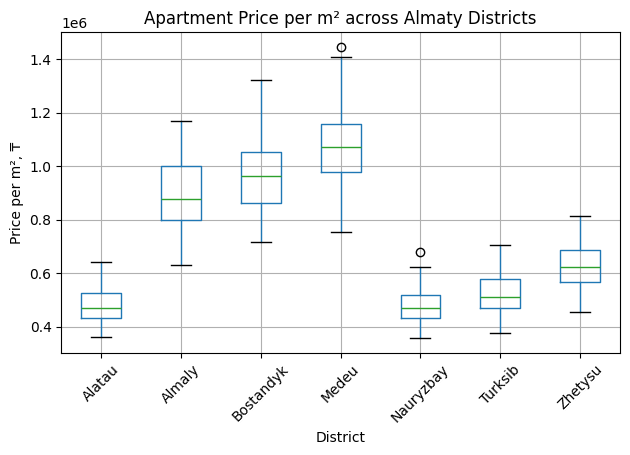

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
df.boxplot(column="price_per_m2", by="district", rot=45)
plt.ylabel("Price per m², ₸")
plt.xlabel("District")
plt.title("Apartment Price per m² across Almaty Districts")
plt.suptitle("")
plt.tight_layout()
plt.show()

**Observation 1:**  
Medeu is the most expensive district with a median price of approximately **1,071,939 ₸/m²**, which is more than double the median price in Alatau (**468,538 ₸/m²**).

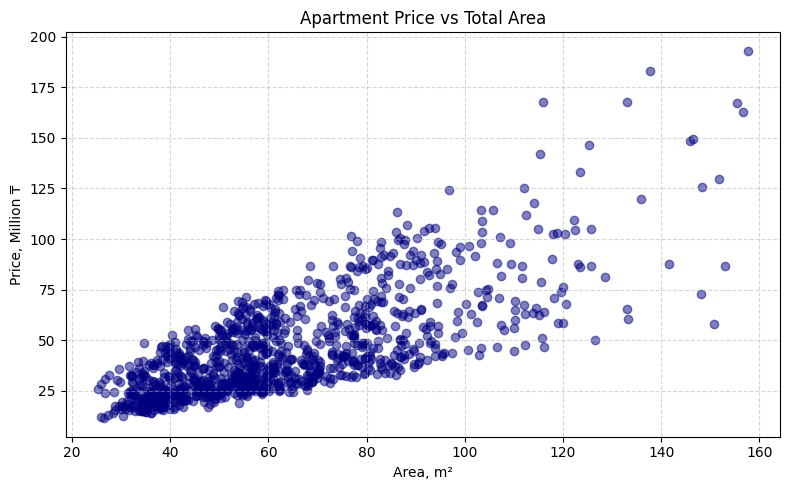

In [18]:
plt.figure(figsize=(8, 5))
plt.scatter(df["area_m2"], df["price_kzt"] / 1e6, alpha=0.5, color="navy")
plt.xlabel("Area, m²")
plt.ylabel("Price, Million ₸")
plt.title("Apartment Price vs Total Area")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

**Observation 2:**  
Apartment price exhibits a strong positive linear correlation with area (**Pearson r ≈ 0.742**), with prices spanning from 11.4M ₸ for compact 25 m² flats up to 193.0M ₸ for spacious 195 m² flats.

<Figure size 700x500 with 0 Axes>

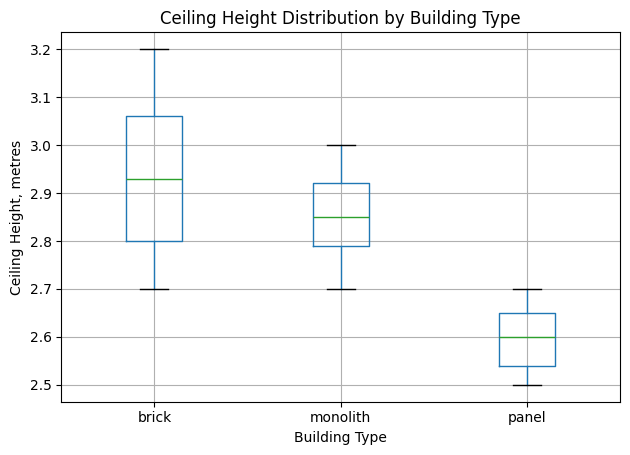

In [19]:
plt.figure(figsize=(7, 5))
df.boxplot(column="ceiling_height_m", by="building_type")
plt.ylabel("Ceiling Height, metres")
plt.xlabel("Building Type")
plt.title("Ceiling Height Distribution by Building Type")
plt.suptitle("")
plt.tight_layout()
plt.show()

**Observation 3:**  
Brick buildings feature the highest median ceiling height at **2.93 metres**, compared to **2.85 metres** in monolith and **2.60 metres** in standard panel blocks.

### 7.2 · Complete Cleaning Log
Summary of all data cleaning operations performed:

In [20]:
log_df = pd.DataFrame(cleaning_log)
print(log_df.to_string(index=False))

   Step                                                    Operation  Rows before  Rows after                                  Cells changed
     3a                                      Remove exact duplicates         1153        1122                                31 rows dropped
     3a                        Resolve reposts (keep latest by date)         1122        1080                                42 rows dropped
     3b                    Standardize district names to 8 canonical         1080        1080               161 district values standardized
     3c                   Parse rooms (studio=1), area_m2, price_kzt         1080        1080 27 studios mapped to 1; all area/price numeric
    4.1     Replace sentinels with NaN (floor=-1, year=0, ceiling=0)         1080        1080                     53 cells replaced with NaN
    4.2 Handle impossible values (floor > total_floors -> floor=NaN)         1080        1080                      9 floor values set to NaN
4.3-4.4      

## Commit History Check
Verify git commit log contains the required commits.

In [21]:
!git log --oneline

4d0797f Step 1: Setup project and environment
95680db Initial commit
